### Spread de precios nodales entre regiones

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


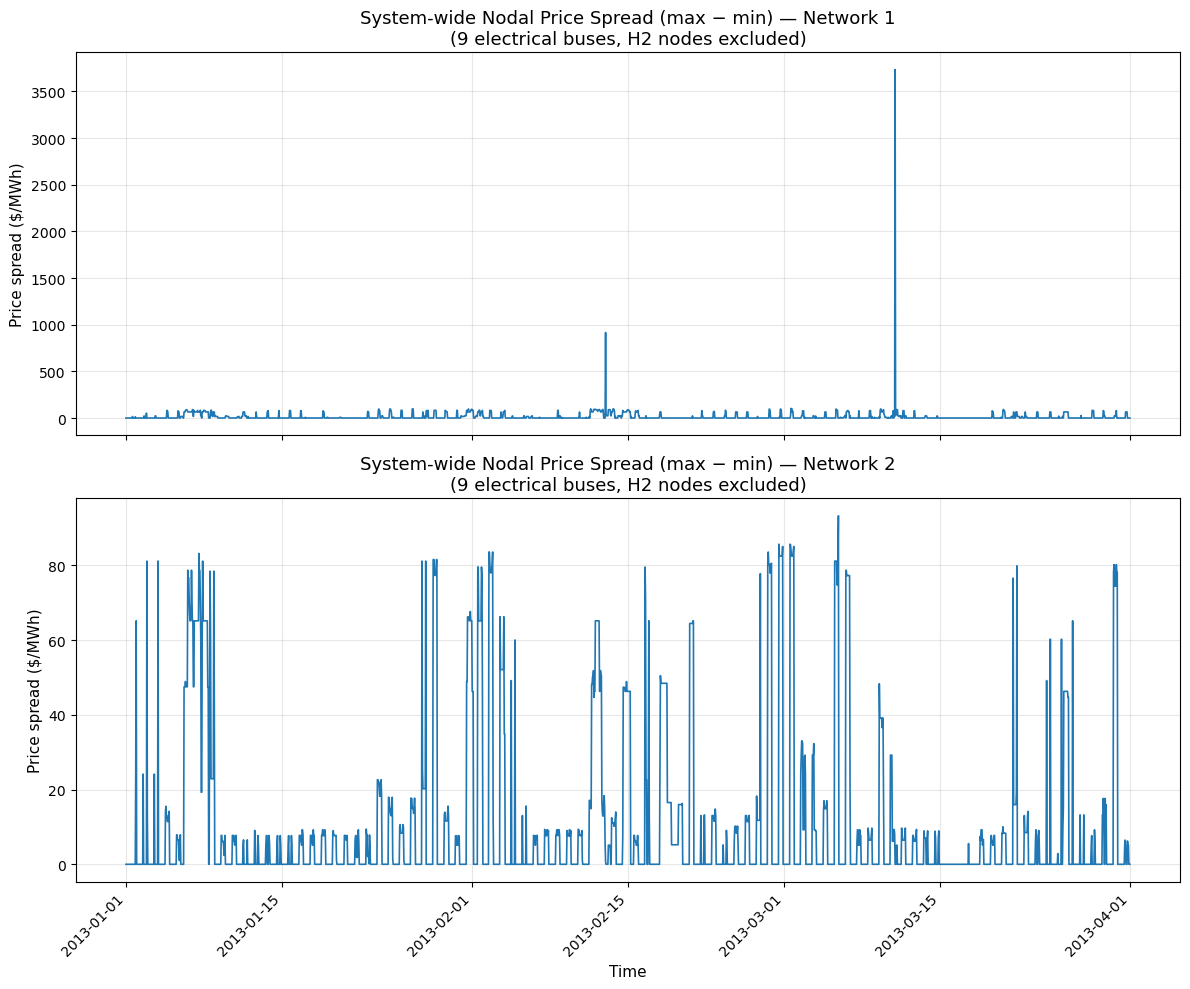


Nodal price spread statistics — Network 1:
count    2161.000000
mean       15.019209
std        86.610433
min         0.000003
25%         0.000014
50%         0.000030
75%         0.008407
max      3734.774427
dtype: float64

Nodal price spread statistics — Network 2:
count    2.161000e+03
mean     1.039494e+01
std      2.126538e+01
min      4.590582e-07
25%      1.639163e-05
50%      1.767781e-03
75%      8.305363e+00
max      9.323393e+01
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

# --- NETWORK PATHS ---
path_1 = #Red1
path_2 = #Red2 - Set to a path string to enable the second plot, or leave as None

# --- LABELS ---
label_1 = "Network 1"
label_2 = "Network 2"

# --- TIME WINDOW ---
start = pd.Timestamp("2013-01-01 00:00:00")
end   = pd.Timestamp("2013-04-01 00:00:00")


def compute_spread(path, start, end):
    """Load a network and return the nodal price spread series, excluding H2 buses."""
    n = pypsa.Network(path)

    # --- FILTER OUT H2 BUSES ---
    all_buses = n.buses_t.marginal_price.columns
    elec_buses = [b for b in all_buses if "H2" not in b]
    
    prices = n.buses_t.marginal_price.loc[start:end, elec_buses]
    spread = prices.max(axis=1) - prices.min(axis=1)
    return spread, elec_buses


# --- LOAD NETWORKS ---
spread_1, buses_1 = compute_spread(path_1, start, end)
spread_2, buses_2 = compute_spread(path_2, start, end) if path_2 else (None, None)

# --- PLOT ---
n_plots = 2 if spread_2 is not None else 1
fig, axes = plt.subplots(n_plots, 1, figsize=(12, 5 * n_plots), sharex=True)

if n_plots == 1:
    axes = [axes]

def plot_spread(ax, spread, label, buses):
    ax.plot(spread.index, spread, linewidth=1.2)
    ax.set_title(f"System-wide Nodal Price Spread (max − min) — {label}\n"
                 f"({len(buses)} electrical buses, H2 nodes excluded)", fontsize=13)
    ax.set_ylabel("Price spread ($/MWh)", fontsize=11)
    ax.grid(True, alpha=0.3)

plot_spread(axes[0], spread_1, label_1, buses_1)

if spread_2 is not None:
    plot_spread(axes[1], spread_2, label_2, buses_2)

axes[-1].set_xlabel("Time", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- STATS ---
for label, spread in [(label_1, spread_1), (label_2, spread_2)]:
    if spread is not None:
        print(f"\nNodal price spread statistics — {label}:")
        print(spread.describe())

### Comparar precio nodales de distintas redes para mismo lugar y momento

In [ ]:
import pypsa
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# --- CONFIGURATION ---
# Set path to None to use only one network
PATH_N1 = #Red1
PATH_N2 = #Red2
# PATH_N2 = None  # <-- uncomment to use only one network

# Time window
start = pd.Timestamp("2013-09-01 00:00:00")
end   = pd.Timestamp("2013-09-15 00:00:00")

# Bus names: leave as empty list [] for system-wide average
bus_names = ["AR.NOA"]

# --- LOAD NETWORKS ---
networks = {"50ALTO+": pypsa.Network(PATH_N1)}
if PATH_N2 is not None:
    networks["Red Actual"] = pypsa.Network(PATH_N2)

# --- PLOT ---
fig, ax = plt.subplots(figsize=(12, 6))
linestyles = ["-", "-"]

for (label, n), ls in zip(networks.items(), linestyles):
    prices = n.buses_t.marginal_price
    prices = prices.loc[start:end]

    if not bus_names:
        series = prices.mean(axis=1)
        ax.plot(series.index, series, linewidth=1.2, linestyle=ls,
                label=f"{label} — system average")
    else:
        for bus in bus_names:
            if bus not in prices.columns:
                print(f"Warning: bus '{bus}' not found in {label}, skipping.")
                continue
            ax.plot(prices.index, prices[bus], linewidth=1.2, linestyle=ls,
                    label=f"{label} — {bus}")

bus_str = "system average" if not bus_names else ", ".join(bus_names)
ax.set_ylabel("Precio Marginal en NOA (USD / MWh)", fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- STATISTICS ---
print(f"\nStatistics ({start.date()} to {end.date()}):")
for label, n in networks.items():
    prices = n.buses_t.marginal_price.loc[start:end]
    if not bus_names:
        s = prices.mean(axis=1)
        print(f"\n{label} — system average:")
        print(f"  Mean:   {s.mean():.2f}")
        print(f"  Median: {s.median():.2f}")
        print(f"  Min:    {s.min():.2f}")
        print(f"  Max:    {s.max():.2f}")
        print(f"  Std:    {s.std():.2f}")
    else:
        for bus in bus_names:
            if bus not in prices.columns:
                continue
            s = prices[bus]
            print(f"\n{label} — {bus}:")
            print(f"  Mean:   {s.mean():.2f}")
            print(f"  Median: {s.median():.2f}")
            print(f"  Min:    {s.min():.2f}")
            print(f"  Max:    {s.max():.2f}")
            print(f"  Std:    {s.std():.2f}")

### Mapa precios nodales por region

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units
c:\Users\ariel\mambaforge\Library\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


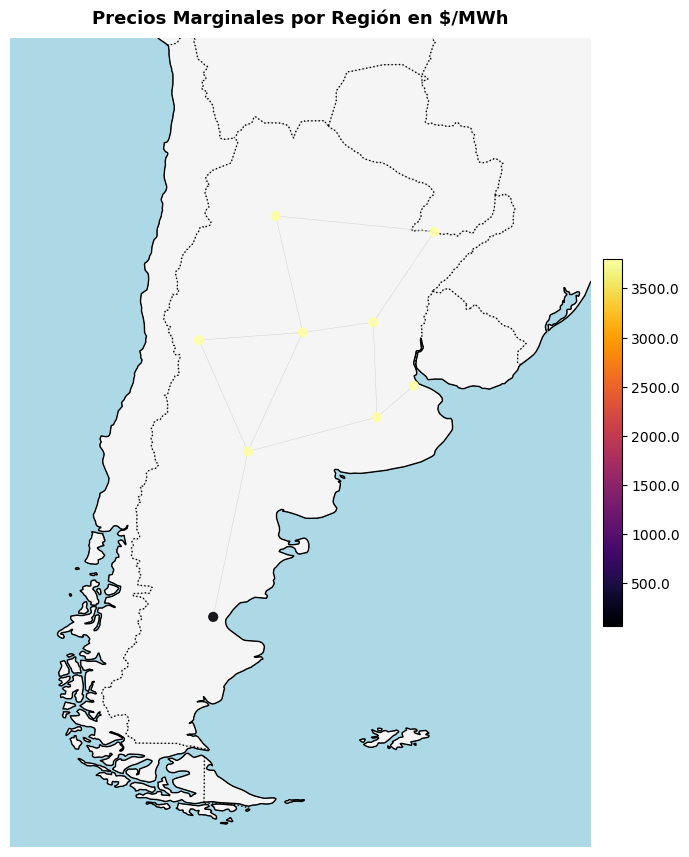

,Marginal Price ($/MWh)
Bus,
AR.BAS,3799.94
AR.CEN,3799.94
AR.COM,3799.94
AR.CUY,3799.94
AR.GBA,3799.94
AR.LIT,3799.94
AR.NEA,3799.94
AR.NOA,3799.94
AR.PAT,65.17



Marginal price statistics — 2013-03-10 23:00:00  |  9 electrical buses (H2 excluded)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FormatStrFormatter

import pypsa
n = #RED A ANALIZAR

# --- NODAL PRICES (H2 buses excluded) ---
all_buses = n.buses_t.marginal_price.columns
elec_buses = [b for b in all_buses if "H2" not in b]
prices = n.buses_t.marginal_price[elec_buses]   # snapshots × elec buses only

system_price = prices.mean(axis=1)

# ─────────────────────────────────────────
# SET YOUR SNAPSHOT HERE
snap = pd.Timestamp("2013-03-10 23:00:00")
# ─────────────────────────────────────────

# --- PLOT FUNCTION ---
def plot_price_map(p_bus, title, cmap="inferno"):
    vmin = float(p_bus.min())
    vmax = float(p_bus.max())
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={"projection": ccrs.PlateCarree()})

    n.plot(
        ax=ax,
        bus_sizes=0.06,
        bus_colors=p_bus,
        bus_cmap=cmap,
        bus_norm=norm,
        branch_components=["Line"],
        line_widths=0.35,
        line_colors="lightgray",
        bus_alpha=0.9,
        color_geomap=True,
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.set_xlim([-78, -50])
    ax.set_ylim([-57, -18])
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.formatter = FormatStrFormatter("%.1f")
    cbar.update_ticks()

    plt.tight_layout()
    plt.show()

# --- PLOT ---
if snap not in prices.index:
    raise ValueError(f"Snapshot {snap} not found in index. Available range: {prices.index[0]} → {prices.index[-1]}")

sys_avg = float(system_price.loc[snap])
plot_price_map(prices.loc[snap], f"Precios Marginales por Región en $/MWh")

# --- STATS TABLE ---
p_snap = prices.loc[snap].rename("Marginal Price ($/MWh)").round(2)
p_snap.index.name = "Bus"
display(p_snap.to_frame())

print(f"\nMarginal price statistics — {snap}  |  {len(elec_buses)} electrical buses (H2 excluded)")

### Despacho en una region y una hora especifica

In [ ]:
bus = "AR.GBA"
snap = pd.Timestamp("2013-03-10 23:00:00")

print("Bus price:", n.buses_t.marginal_price.loc[snap, bus])

gen = n.generators[n.generators.bus == bus]

table = gen[["carrier","marginal_cost", "p_nom", "p_nom_opt"]].copy()
table["dispatch"] = n.generators_t.p.loc[snap, gen.index]

display(table.sort_values("dispatch", ascending=False))

Bus price: 46.07880531398656


,carrier,marginal_cost,p_nom,p_nom_opt,dispatch
Generator,,,,,
AR.GBA CCGT,CCGT,46.079794,3267.00000,3267.000000,2.317804
AR.GBA solar,solar,0.024778,0.00000,0.002463,0.001515
AR.GBA onwind,onwind,0.024329,0.00000,0.000335,0.000150
AR.GBA OCGT,OCGT,62.344992,1719.00000,1719.000121,0.000143
AR.GBA load shedding,load shedding,3800.009858,13927.34088,13927.340880,0.000004


### Estado Storage

In [39]:
su = n.storage_units[n.storage_units.bus == bus]

table = su[["carrier","marginal_cost","p_nom"]].copy()
table["dispatch"] = n.storage_units_t.p.loc[snap, su.index]
table["soc"] = n.storage_units_t.state_of_charge.loc[snap, su.index]

display(table)

,carrier,marginal_cost,p_nom,dispatch,soc
StorageUnit,,,,,
AR.CEN PHS,PHS,0.00992,750.0,-749.99927,11230.142637


### Congestion

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units
c:\Users\ariel\mambaforge\Library\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


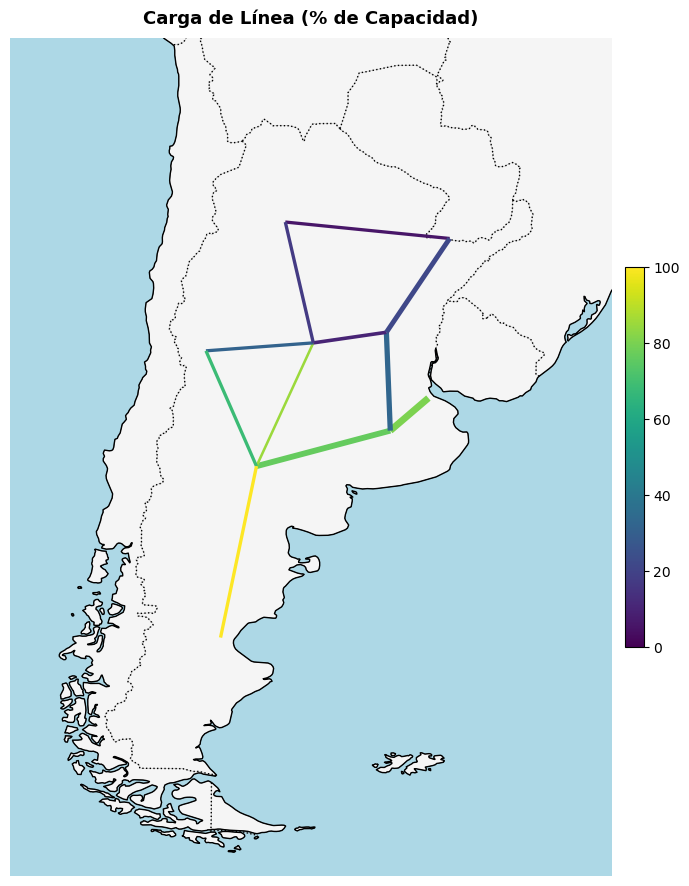

,Loading (% of s_nom)
Line,
0,76.52
1,80.12
10,5.71
2,32.71
3,84.95
4,31.33
5,10.00
6,17.52
7,68.11


In [ ]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- LOAD SOLVED NETWORK ---
n1 = #Red a analizar

# ─────────────────────────────────────────
# SET YOUR SNAPSHOT HERE
snap = pd.Timestamp("2013-03-10 23:00:00")
# ─────────────────────────────────────────

# --- CAPACITY ---
s_nom = n1.lines["s_nom"].replace(0, np.nan)

# --- LOADING AT SNAPSHOT (% of s_nom) ---
flow_snap = np.maximum(
    n1.lines_t.p0.loc[snap].abs(),
    n1.lines_t.p1.loc[snap].abs()
)
loading_pct = (100.0 * flow_snap.div(s_nom)).clip(lower=0.0, upper=100.0)
line_colors = loading_pct.reindex(n1.lines.index).fillna(0.0)

# --- LINE WIDTHS ---
line_widths = (1.8 + n1.lines.s_nom / 4000.0).clip(lower=1.8)

# --- COLOR NORMALIZATION ---
norm = colors.Normalize(vmin=0.0, vmax=100.0)

# --- PLOT ---
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={"projection": ccrs.PlateCarree()})

n1.plot(
    ax=ax,
    branch_components=["Line"],
    line_widths=line_widths,
    line_colors=line_colors,
    line_cmap=plt.cm.viridis,
    line_norm=norm,
    bus_sizes=0,
    bus_colors="gray",
    color_geomap=True,
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_xlim([-78, -50])
ax.set_ylim([-57, -18])
ax.set_title(f"Carga de Línea (% de Capacidad)", fontsize=13, fontweight="bold", pad=10)

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_ticks([0, 20, 40, 60, 80, 100])

plt.tight_layout()
plt.show()

# --- STATS TABLE ---
loading_table = loading_pct.rename("Loading (% of s_nom)").round(2)
loading_table.index.name = "Line"
display(loading_table.to_frame())

### Flujo energético entre regiones para una sola hora

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.05_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units
C:\Users\ariel\AppData\Local\Temp\ipykernel_18364\2826391894.py:269: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



TOTAL SYSTEM ANALYSIS
Snapshot: 2013-03-01 16:00:00

Regional Summary (MW):

        production  consumption  imports  exports  net_import
region                                                       
AR.GBA         2.3       7435.6   7433.3      0.0      7433.3
AR.BAS      2721.5       2937.6   7649.4   7433.3       216.1
AR.LIT      1968.9       3573.6   5026.7   3422.0      1604.7
AR.CEN       954.5       1968.4   4039.6   3025.7      1013.9
AR.NOA      6159.4       1598.5      0.0   4560.9     -4560.9
AR.NEA      1666.7       1841.0   2234.3   2060.0       174.3
AR.COM      2598.5        792.5   2421.4   4227.4     -1806.0
AR.CUY      4976.1       1028.8      0.0   3947.3     -3947.3
AR.PAT       728.3        600.3      0.0    128.1      -128.1

System Totals:
Total Production:         21,776.3 MW
Total Consumption:        21,776.3 MW
Balance:             0.0 MW

Plot saved as: system_energy_analysis.png


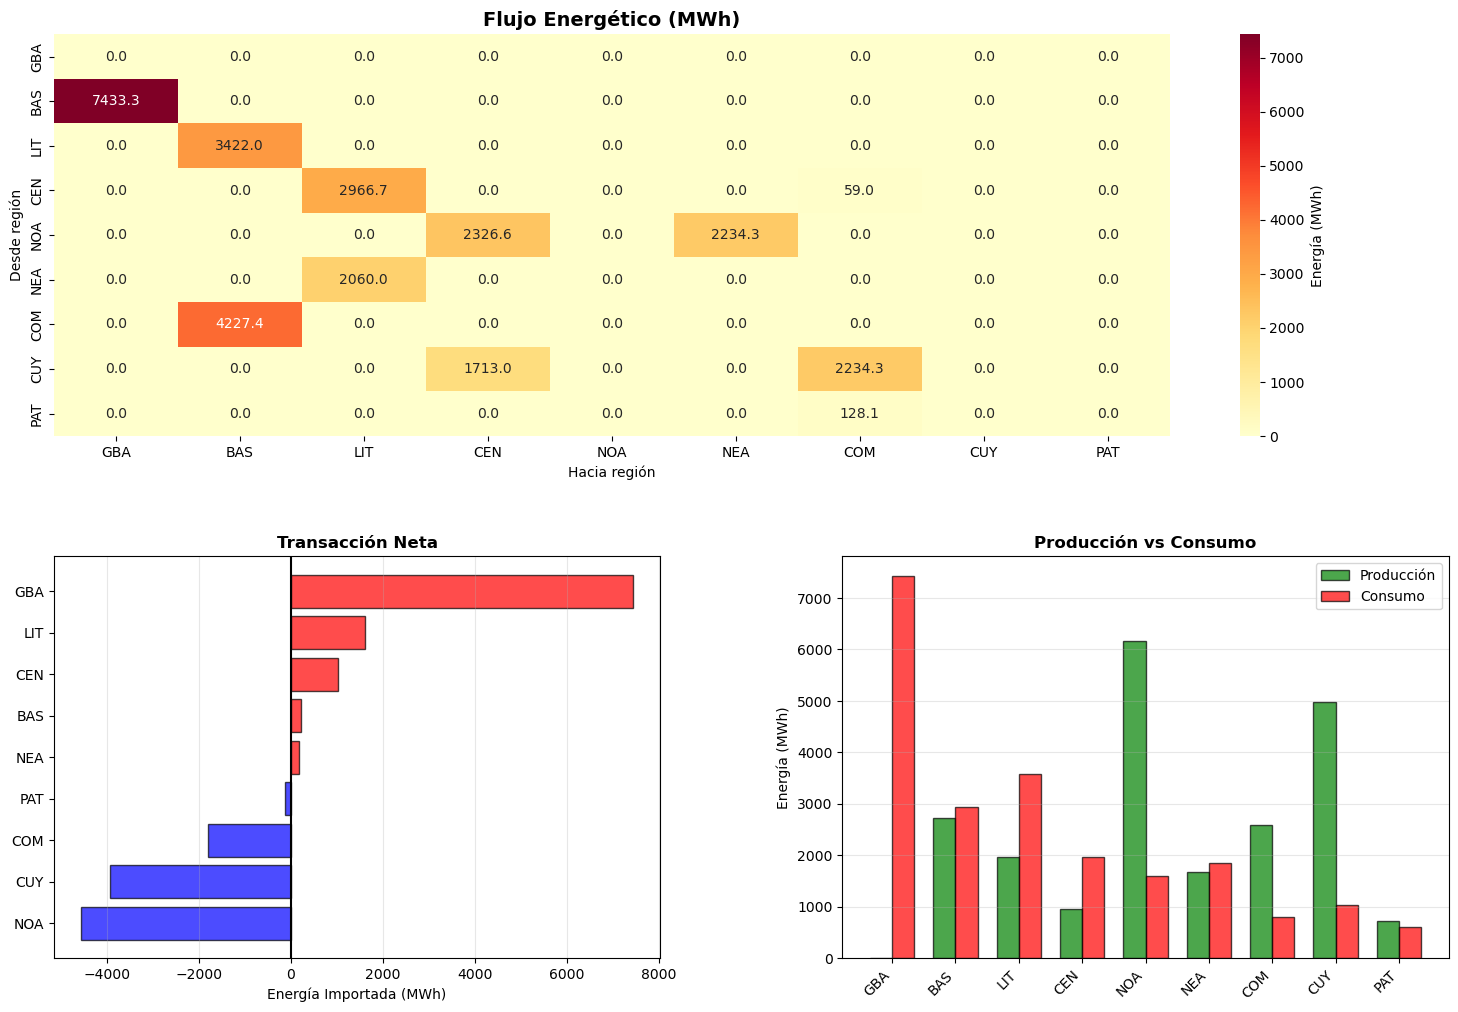

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pypsa
n = #Red
# ========================================
# USER INPUT
# ========================================
selected_bus = ""  # Change this to any bus name, or "" for total system
snapshot = pd.Timestamp("2013-03-01 16:00:00")  # Single snapshot to analyze

REGION_BUSES = [
    "AR.GBA", "AR.BAS", "AR.LIT", "AR.CEN", "AR.NOA",
    "AR.NEA", "AR.COM", "AR.CUY", "AR.PAT"
]
# ========================================


def get_snapshots(n, snapshot):
    """Get a single snapshot."""
    if snapshot not in n.snapshots:
        raise ValueError(f"Snapshot {snapshot} not found in network snapshots")
    return n.snapshots[n.snapshots == snapshot]


def calculate_bus_production_consumption(n, bus_name, snapshots):
    """Calculate production and consumption for a single bus (in MW)."""
    results = {'production': 0.0, 'consumption': 0.0}
    
    gens = n.generators[n.generators.bus == bus_name].index
    if len(gens) > 0:
        results['production'] = n.generators_t.p[gens].loc[snapshots].sum().sum()
    
    storage = n.storage_units[n.storage_units.bus == bus_name].index
    if len(storage) > 0:
        discharge = n.storage_units_t.p[storage].loc[snapshots].clip(lower=0).sum().sum()
        results['production'] += discharge
    
    loads = n.loads[n.loads.bus == bus_name].index
    if len(loads) > 0:
        results['consumption'] = n.loads_t.p_set[loads].loc[snapshots].sum().sum()
    
    if len(storage) > 0:
        charge = (-n.storage_units_t.p[storage].loc[snapshots]).clip(lower=0).sum().sum()
        results['consumption'] += charge
    
    return results


def calculate_trade_matrix(n, region_buses, snapshots):
    """
    Calculate directional trade matrix between regions (in MW).
    E[i,j] = power flowing from region i to region j
    """
    regions = pd.Index(region_buses)
    E = pd.DataFrame(0.0, index=regions, columns=regions)

    # AC Lines
    flows = n.lines_t.p0.loc[snapshots]  # DataFrame: snapshots x lines
    for idx, line in n.lines.iterrows():
        bus0, bus1 = line['bus0'], line['bus1']
        if bus0 in regions and bus1 in regions and bus0 != bus1:
            if idx not in flows.columns:
                continue
            flow_val = float(flows[idx].sum())  # single snapshot so sum = value
            if flow_val >= 0:
                E.loc[bus0, bus1] += flow_val
            else:
                E.loc[bus1, bus0] += -flow_val

    # DC Links
    if hasattr(n, 'links_t') and hasattr(n.links_t, 'p0') and len(n.links) > 0:
        link_flows = n.links_t.p0.loc[snapshots]
        for idx, link in n.links.iterrows():
            bus0, bus1 = link['bus0'], link['bus1']
            if bus0 in regions and bus1 in regions and bus0 != bus1:
                if idx not in link_flows.columns:
                    continue
                flow_val = float(link_flows[idx].sum())
                if flow_val >= 0:
                    E.loc[bus0, bus1] += flow_val
                else:
                    E.loc[bus1, bus0] += -flow_val

    exports = E.sum(axis=1)
    imports = E.sum(axis=0)
    net_import = imports - exports

    return E, imports, exports, net_import


# =========================
# MAIN ANALYSIS
# =========================

snapshots = get_snapshots(n, snapshot)

if selected_bus and selected_bus != "" and selected_bus != "None":
    # ===== SINGLE BUS ANALYSIS =====
    if selected_bus not in REGION_BUSES:
        print(f"ERROR: Bus '{selected_bus}' not found")
        print(f"\nAvailable buses: {REGION_BUSES}")
        raise ValueError(f"Bus '{selected_bus}' not found")

    results = calculate_bus_production_consumption(n, selected_bus, snapshots)
    E, imports, exports, net_import = calculate_trade_matrix(n, REGION_BUSES, snapshots)

    results['import'] = imports.loc[selected_bus]
    results['export'] = exports.loc[selected_bus]
    results['net_import'] = net_import.loc[selected_bus]

    print(f"\n{'='*70}")
    print(f"Energy Balance for Bus: {selected_bus}")
    print(f"Snapshot: {snapshot}")
    print(f"{'='*70}")
    print(f"Production:  {results['production']:>15,.1f} MW")
    print(f"Consumption: {results['consumption']:>15,.1f} MW")
    print(f"Import:      {results['import']:>15,.1f} MW")
    print(f"Export:      {results['export']:>15,.1f} MW")
    print(f"Net Import:  {results['net_import']:>15,.1f} MW")
    print(f"{'='*70}")

    balance = (results['production'] + results['import'] -
               results['consumption'] - results['export'])
    print(f"Balance check (should be ~0): {balance:>15,.1f} MW ({balance/results['consumption']*100:.2f}%)")
    print(f"{'='*70}\n")

    imports_from = E[selected_bus]
    imports_from = imports_from[imports_from > 0].sort_values(ascending=False)

    exports_to = E.loc[selected_bus]
    exports_to = exports_to[exports_to > 0].sort_values(ascending=False)

    if len(imports_from) > 0:
        print(f"Imports from:")
        for region, value in imports_from.items():
            print(f"  {region}: {value:>12,.1f} MW")

    if len(exports_to) > 0:
        print(f"\nExports to:")
        for region, value in exports_to.items():
            print(f"  {region}: {value:>12,.1f} MW")

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    categories = ['Production', 'Consumption', 'Import', 'Export']
    values = [results['production'], results['consumption'],
              results['import'], results['export']]
    colors = ['green', 'red', 'blue', 'orange']

    ax1.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_ylabel('Power (MW)')
    ax1.set_title(f'Energy Balance - {selected_bus}')
    ax1.grid(True, alpha=0.3, axis='y')

    if results['production'] > 0 or results['import'] > 0:
        supply_labels = []
        supply_values = []
        if results['production'] > 0:
            supply_labels.append(f"Production\n{results['production']:,.1f} MW")
            supply_values.append(results['production'])
        if results['import'] > 0:
            supply_labels.append(f"Import\n{results['import']:,.1f} MW")
            supply_values.append(results['import'])

        ax2.pie(supply_values, labels=supply_labels, autopct='%1.1f%%',
                startangle=90, colors=['green', 'blue'])
        ax2.set_title('Supply Mix')

    if len(imports_from) > 0:
        ax3.barh(imports_from.index.astype(str), imports_from.values, color='blue', alpha=0.7)
        ax3.set_xlabel('Power (MW)')
        ax3.set_title(f'Imports to {selected_bus}')
        ax3.grid(True, alpha=0.3, axis='x')
    else:
        ax3.text(0.5, 0.5, 'No Imports', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title(f'Imports to {selected_bus}')

    if len(exports_to) > 0:
        ax4.barh(exports_to.index.astype(str), exports_to.values, color='orange', alpha=0.7)
        ax4.set_xlabel('Power (MW)')
        ax4.set_title(f'Exports from {selected_bus}')
        ax4.grid(True, alpha=0.3, axis='x')
    else:
        ax4.text(0.5, 0.5, 'No Exports', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title(f'Exports from {selected_bus}')

    plt.tight_layout()
    filename = f"energy_balance_{selected_bus}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved as: {filename}")
    plt.show()

else:
    # ===== TOTAL SYSTEM ANALYSIS =====
    print("\n" + "="*70)
    print("TOTAL SYSTEM ANALYSIS")
    print(f"Snapshot: {snapshot}")
    print("="*70)

    region_data = []
    for bus in REGION_BUSES:
        bus_results = calculate_bus_production_consumption(n, bus, snapshots)
        region_data.append({
            'region': bus,
            'production': bus_results['production'],
            'consumption': bus_results['consumption']
        })

    region_df = pd.DataFrame(region_data).set_index('region')

    E, imports, exports, net_import = calculate_trade_matrix(n, REGION_BUSES, snapshots)

    region_df['imports'] = imports
    region_df['exports'] = exports
    region_df['net_import'] = net_import

    print("\nRegional Summary (MW):\n")
    print(region_df.round(1))

    total_production = region_df['production'].sum()
    total_consumption = region_df['consumption'].sum()
    print(f"\n{'='*70}")
    print(f"System Totals:")
    print(f"Total Production:  {total_production:>15,.1f} MW")
    print(f"Total Consumption: {total_consumption:>15,.1f} MW")
    print(f"Balance: {total_production - total_consumption:>15,.1f} MW")
    print(f"{'='*70}\n")

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, :])
    sns.heatmap(E, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax1,
                xticklabels=[b.replace('AR.', '') for b in REGION_BUSES],
                yticklabels=[b.replace('AR.', '') for b in REGION_BUSES],
                cbar_kws={'label': 'Energía (MWh)'})
    ax1.set_title('Flujo Energético (MWh)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Hacia región')
    ax1.set_ylabel('Desde región')

    ax2 = fig.add_subplot(gs[1, 0])
    net_bars = region_df['net_import'].sort_values()
    colors_net = ['blue' if x < 0 else 'red' for x in net_bars]
    ax2.barh([b.replace('AR.', '') for b in net_bars.index], net_bars.values,
             color=colors_net, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Energía Importada (MWh)')
    ax2.set_title('Transacción Neta', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.axvline(x=0, color='black', linewidth=1.5)

    ax3 = fig.add_subplot(gs[1, 1])
    x = np.arange(len(REGION_BUSES))
    width = 0.35
    ax3.bar(x - width/2, region_df['production'], width, label='Production',
            color='green', alpha=0.7, edgecolor='black')
    ax3.bar(x + width/2, region_df['consumption'], width, label='Consumption',
            color='red', alpha=0.7, edgecolor='black')
    ax3.set_ylabel('Energía (MWh)')
    ax3.set_title('Producción vs Consumo', fontweight='bold')
    ax3.legend(labels=['Producción', 'Consumo'])
    ax3.set_xticks(x)
    ax3.set_xticklabels([b.replace('AR.', '') for b in REGION_BUSES], rotation=45, ha='right')
    ax3.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    filename = "system_energy_analysis.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved as: {filename}")
    plt.show()